<a href="https://colab.research.google.com/github/razankablan/razankablan-data-analysis-exercises/blob/main/Module_7_Financial_Data_Preparation_with_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Lab Overview
Welcome to the lab on financial data preparation! In this exercise, you'll use Python and Pandas to clean, transform, and analyze historical price data for Bitcoin and the S&P 500 index.

---

## 🎯 Learning Goals
- Import financial data using `yfinance`
- Clean and merge datasets
- Calculate returns and volatility
- Visualize trends and correlations
- Compute Sharpe Ratios

---

## 📦 Step 1: Install and Import Libraries


In [1]:
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use('seaborn-v0_8-darkgrid')

Step-by-step setup with yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define tickers and date range
tickers = ['BTC-USD', '^GSPC']
start_date = '2020-01-01'
end_date = '2025-01-01'

# Download data
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)





[*********************100%***********************]  2 of 2 completed


Visualize with plotting

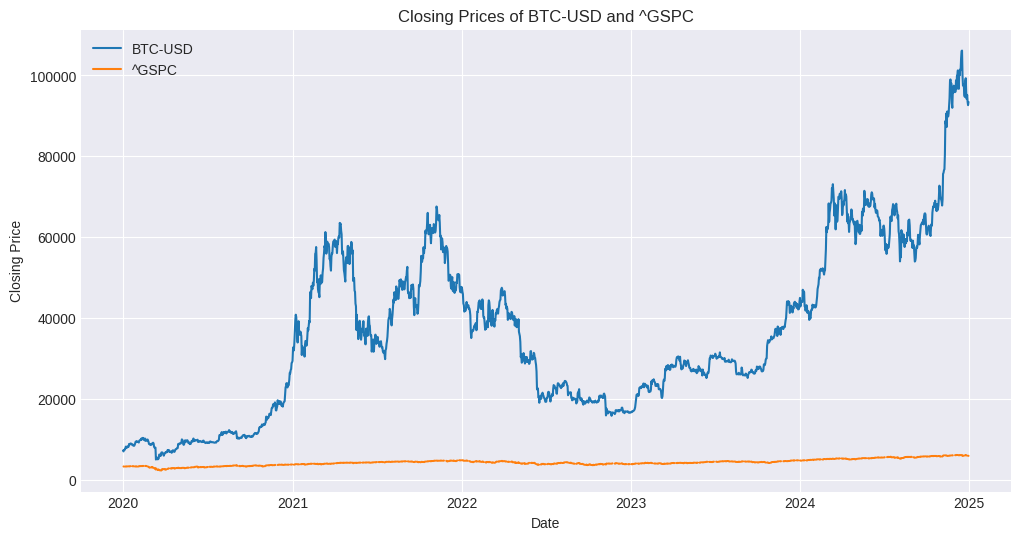

In [3]:
# Visualize closing prices
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[('Close', 'BTC-USD')], label='BTC-USD')
plt.plot(data.index, data[('Close', '^GSPC')], label='^GSPC')
plt.title('Closing Prices of BTC-USD and ^GSPC')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Calculate daily returns
returns = data['Close'].pct_change(fill_method=None)
returns.columns = ['BTC-USD_Returns', '^GSPC_Returns']

# Calculate volatility (standard deviation of daily returns)
btc_volatility = returns['BTC-USD_Returns'].std()
gspc_volatility = returns['^GSPC_Returns'].std()

# Print results
print(f"Bitcoin Volatility (Daily Standard Deviation): {btc_volatility:.4f}")
print(f"S&P 500 Volatility (Daily Standard Deviation): {gspc_volatility:.4f}")

Bitcoin Volatility (Daily Standard Deviation): 0.0335
S&P 500 Volatility (Daily Standard Deviation): 0.0132


In [5]:
# Calculate daily returns
data['BTC-USD_Returns'] = data[('Close', 'BTC-USD')].pct_change()
data['^GSPC_Returns'] = data[('Close', '^GSPC')].pct_change()

# Display the first few rows with returns
display(data.head())

/tmp/ipython-input-4177717000.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['^GSPC_Returns'] = data[('Close', '^GSPC')].pct_change()


Price             Close                      High                       Low  \
Ticker          BTC-USD        ^GSPC      BTC-USD        ^GSPC      BTC-USD   
Date                                                                          
2020-01-01  7200.174316          NaN  7254.330566          NaN  7174.944336   
2020-01-02  6985.470215  3257.850098  7212.155273  3258.139893  6935.270020   
2020-01-03  7344.884277  3234.850098  7413.715332  3246.149902  6914.996094   
2020-01-04  7410.656738          NaN  7427.385742          NaN  7309.514160   
2020-01-05  7411.317383          NaN  7544.497070          NaN  7400.535645   

Price                           Open                    Volume                \
Ticker            ^GSPC      BTC-USD        ^GSPC      BTC-USD         ^GSPC   
Date                                                                           
2020-01-01          NaN  7194.892090          NaN  18565664997           NaN   
2020-01-02  3235.530029  7202.551270  3244.669922  20802083465  3.459930e+09   
2020-01-03  3222.340088  6984.428711  3226.360107  28111481032  3.484700e+09   
2020-01-04          NaN  7345.375488          NaN  18444271275           NaN   
2020-01-05          NaN  7410.451660          NaN  19725074095           NaN   

Price      BTC-USD_Returns ^GSPC_Returns  
Ticker                                    
Date                                      
2020-01-01             NaN           NaN  
2020-01-02       -0.029819           NaN  
2020-01-03        0.051452      -0.00706  
2020-01-04        0.008955       0.00000  
2020-01-05        0.000089       0.00000

In [6]:
# Forward-fill missing values
data.fillna(method='ffill', inplace=True)

# Display the first few rows to check for NaNs
display(data.head())

# Check for remaining NaNs
display(data.isnull().sum())

/tmp/ipython-input-1256242487.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


Price             Close                      High                       Low  \
Ticker          BTC-USD        ^GSPC      BTC-USD        ^GSPC      BTC-USD   
Date                                                                          
2020-01-01  7200.174316          NaN  7254.330566          NaN  7174.944336   
2020-01-02  6985.470215  3257.850098  7212.155273  3258.139893  6935.270020   
2020-01-03  7344.884277  3234.850098  7413.715332  3246.149902  6914.996094   
2020-01-04  7410.656738  3234.850098  7427.385742  3246.149902  7309.514160   
2020-01-05  7411.317383  3234.850098  7544.497070  3246.149902  7400.535645   

Price                           Open                    Volume                \
Ticker            ^GSPC      BTC-USD        ^GSPC      BTC-USD         ^GSPC   
Date                                                                           
2020-01-01          NaN  7194.892090          NaN  18565664997           NaN   
2020-01-02  3235.530029  7202.551270  3244.669922  20802083465  3.459930e+09   
2020-01-03  3222.340088  6984.428711  3226.360107  28111481032  3.484700e+09   
2020-01-04  3222.340088  7345.375488  3226.360107  18444271275  3.484700e+09   
2020-01-05  3222.340088  7410.451660  3226.360107  19725074095  3.484700e+09   

Price      BTC-USD_Returns ^GSPC_Returns  
Ticker                                    
Date                                      
2020-01-01             NaN           NaN  
2020-01-02       -0.029819           NaN  
2020-01-03        0.051452      -0.00706  
2020-01-04        0.008955       0.00000  
2020-01-05        0.000089       0.00000

Price            Ticker 
Close            BTC-USD    0
                 ^GSPC      1
High             BTC-USD    0
                 ^GSPC      1
Low              BTC-USD    0
                 ^GSPC      1
Open             BTC-USD    0
                 ^GSPC      1
Volume           BTC-USD    0
                 ^GSPC      1
BTC-USD_Returns             1
^GSPC_Returns               2
dtype: int64

In [7]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Freq: D
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, BTC-USD)     1827 non-null   float64
 1   (Close, ^GSPC)       1826 non-null   float64
 2   (High, BTC-USD)      1827 non-null   float64
 3   (High, ^GSPC)        1826 non-null   float64
 4   (Low, BTC-USD)       1827 non-null   float64
 5   (Low, ^GSPC)         1826 non-null   float64
 6   (Open, BTC-USD)      1827 non-null   float64
 7   (Open, ^GSPC)        1826 non-null   float64
 8   (Volume, BTC-USD)    1827 non-null   int64  
 9   (Volume, ^GSPC)      1826 non-null   float64
 10  (BTC-USD_Returns, )  1826 non-null   float64
 11  (^GSPC_Returns, )    1825 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 185.6 KB


None

In [9]:
# Define the tickers and time period
tickers = ["BTC-USD", "^GSPC"]  # Bitcoin and S&P 500
start_date = "2018-01-01"
end_date = "2023-12-31"

# Download the data
data = yf.download(tickers, start=start_date, end=end_date)

# Display the first few rows of the data
display(data.head())

/tmp/ipython-input-4137493875.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed


Price              Close                       High               \
Ticker           BTC-USD        ^GSPC       BTC-USD        ^GSPC   
Date                                                               
2018-01-01  13657.200195          NaN  14112.200195          NaN   
2018-01-02  14982.099609  2695.810059  15444.599609  2695.889893   
2018-01-03  15201.000000  2713.060059  15572.799805  2714.370117   
2018-01-04  15599.200195  2723.989990  15739.700195  2729.290039   
2018-01-05  17429.500000  2743.149902  17705.199219  2743.449951   

Price                Low                       Open                    Volume  \
Ticker           BTC-USD        ^GSPC       BTC-USD        ^GSPC      BTC-USD   
Date                                                                            
2018-01-01  13154.700195          NaN  14112.200195          NaN  10291200000   
2018-01-02  13163.599609  2682.360107  13625.000000  2683.729980  16846600192   
2018-01-03  14844.500000  2697.770020  14978.200195  2697.850098  16871900160   
2018-01-04  14522.200195  2719.070068  15270.700195  2719.310059  21783199744   
2018-01-05  15202.799805  2727.919922  15477.200195  2731.330078  23840899072   

Price                     
Ticker             ^GSPC  
Date                      
2018-01-01           NaN  
2018-01-02  3.397430e+09  
2018-01-03  3.544030e+09  
2018-01-04  3.697340e+09  
2018-01-05  3.239280e+09

---

## 📅 Step 2: Download Historical Data
We'll use Yahoo Finance to download daily price data for Bitcoin (`BTC-USD`) and the S&P 500 (`^GSPC`) from 2020 to 2023.


In [10]:
btc = yf.download('BTC-USD', start='2020-01-01', end='2023-12-31', auto_adjust=True)
sp500 = yf.download('^GSPC', start='2020-01-01', end='2023-12-31', auto_adjust=True)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


---

## 🧹 Step 3: Clean and Merge Data
We'll keep only the closing prices and merge both datasets on their date index.


In [11]:
btc = btc[['Close']].rename(columns={'Close': 'BTC_Close'})
sp500 = sp500[['Close']].rename(columns={'Close': 'SP500_Close'})

df = pd.merge(btc, sp500, left_index=True, right_index=True)
df.dropna(inplace=True)
df.head()


Price,BTC_Close,SP500_Close
Ticker,BTC-USD,^GSPC
Date,,
2020-01-02,6985.470215,3257.850098
2020-01-03,7344.884277,3234.850098
2020-01-06,7769.219238,3246.280029
2020-01-07,8163.692383,3237.179932
2020-01-08,8079.862793,3253.050049


---

## 📈 Step 4: Feature Engineering
Let's calculate daily returns and rolling 30-day volatility for both assets.


In [12]:
df['BTC_Return'] = df['BTC_Close'].pct_change()
df['SP500_Return'] = df['SP500_Close'].pct_change()

df['BTC_Volatility'] = df['BTC_Return'].rolling(window=30).std()
df['SP500_Volatility'] = df['SP500_Return'].rolling(window=30).std()


---

## 📊 Step 5: Visualize Price Trends
We'll plot the closing prices of Bitcoin and the S&P 500 to compare their trajectories.


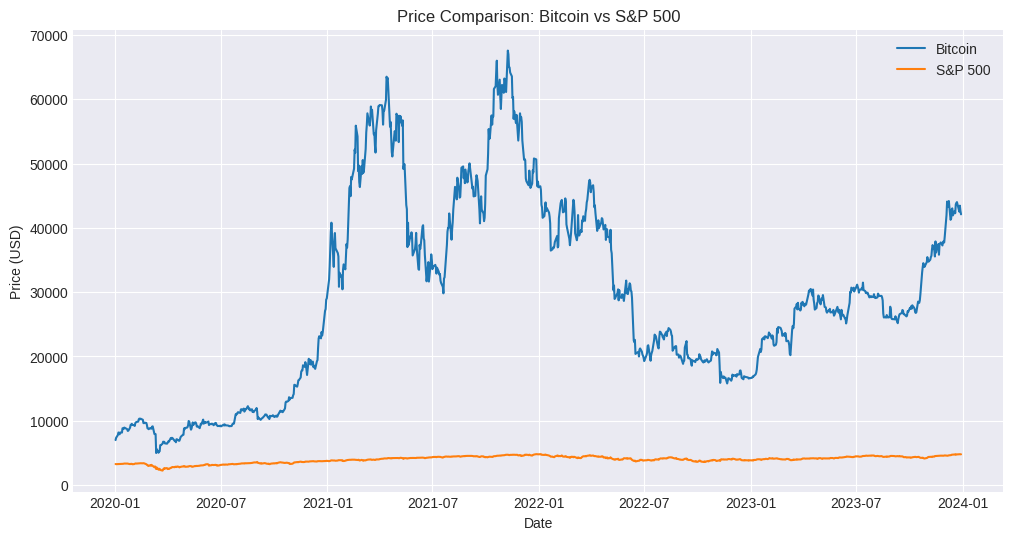

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df['BTC_Close'], label='Bitcoin')
plt.plot(df['SP500_Close'], label='S&P 500')
plt.title('Price Comparison: Bitcoin vs S&P 500')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


---

## 🔍 Step 6: Correlation Analysis
Let's examine how the daily returns of Bitcoin and the S&P 500 are correlated.


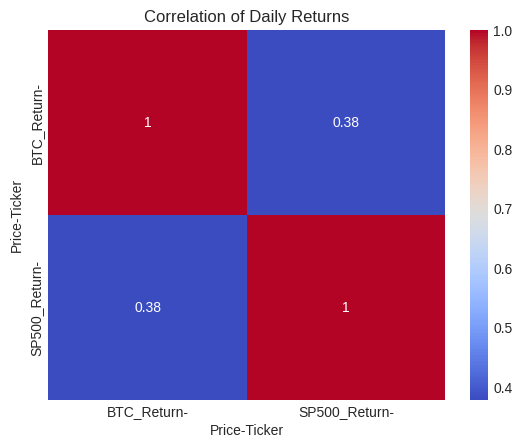

In [14]:
correlation = df[['BTC_Return', 'SP500_Return']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation of Daily Returns')
plt.show()


---

## 📐 Step 7: Sharpe Ratio Calculation
We'll compute the Sharpe Ratio for both assets assuming a 1% annual risk-free rate.


In [15]:
risk_free_rate = 0.01 / 252  # daily rate

btc_sharpe = (df['BTC_Return'].mean() - risk_free_rate) / df['BTC_Return'].std()
sp500_sharpe = (df['SP500_Return'].mean() - risk_free_rate) / df['SP500_Return'].std()

print(f"Bitcoin Sharpe Ratio: {btc_sharpe:.2f}")
print(f"S&P 500 Sharpe Ratio: {sp500_sharpe:.2f}")


Bitcoin Sharpe Ratio: 0.06
S&P 500 Sharpe Ratio: 0.03


---

## 💾 Step 8: Export Cleaned Dataset
Save your prepared dataset for future modeling or visualization.


In [17]:
df.to_csv('prepared_financial_data.csv')


In [18]:
from google.colab import files
files.download('prepared_financial_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## ✅ Lab Complete!
You've successfully cleaned and analyzed financial data using Pandas.
Upload your results in the weekly summary

Happy analyzing!
